# Ejercicio 1 Conceptos b´asicos de la TDF 2D

1. Construya im´agenes binarias de: una l´ınea horizontal, una l´ınea vertical, un
cuadrado centrado, un rect´angulo centrado, un c´ırculo.
¿Qu´e espera ver en las TDF de cada una de est´as? ¿C´omo estima que estar´a
distribuida la energ´ıa?
2. Utilice cada una de las im´agenes anteriores para calcular la TDF y visualice.
¿Se cumplieron sus pron´osticos respecto de sus definiciones?
Var´ıe las dimensiones y localizaci´on de los objetos en estas im´agenes y repita
el an´alisis.
3. Construya una imagen de 512x512, que contenga una l´ınea vertical blanca
centrada y de un pixel de ancho sobre un fondo negro.
Rote la imagen 20 grados y extraiga una secci´on de 256x256 de la imagen
original y de la imagen rotada, de manera que las l´ıneas tengan sus extremos
en los bordes superior e inferior, sin m´argenes.
Visualice la TDF de ambas im´agenes. Explique, utilizando argumentos intuitivos, por qu´e las magnitudes de Fourier aparecen como lo hacen en las
im´agenes, y a qu´e se deben las diferencias.
Ayuda: utilice dst = imutils.rotate(src, angle) de la biblioteca imutils
(https://github.com/jrosebr1/imutils).
4. Cargue diferentes im´agenes y visualice la magnitud de la TDF. Infiera, a
grandes rasgos, la correspondencia entre componentes frecuenciales y detalles
de las im´agenes

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def graph_fft_3d(width, height, magnitude):
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    fig = go.Figure(
        data=[
            go.Surface(
                z=magnitude,
                x=X,
                y=Y
            )
        ]
    )

    fig.update_layout(
        title="Magnitud de la FFT (3D)",
        scene=dict(
            xaxis_title="Frecuencia X",
            yaxis_title="Frecuencia Y",
            zaxis_title="Magnitud"
        ),
        width=800,
        height=700
    )

    fig.show()
    

# Ejercicio 1 y 2

## Lineas horizontales

La linea horizontal como no tiene cambios de frecuencias horizontales pero si los tiene verticales, entonces esperamos ver este comportamiento en las frecuencias verticales de la transformada.

Cualquier funcion sinusoidal

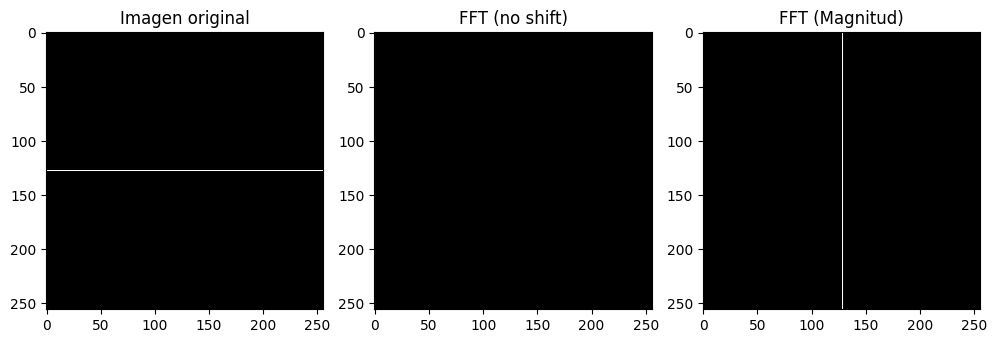

In [2]:

# Parámetros de la imagen
height, width = 256, 256

# Crear imagen negra
img = np.zeros((height, width))

# Dibujar línea horizontal blanca en el centro
img[height // 2, :] = 255

# FFT 2D
fft = np.fft.fft2(img)
fft_shift = np.fft.fftshift(fft)
magnitude = np.log(1 + np.abs(fft_shift))

# Graficar
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.title("Imagen original")
plt.imshow(img, cmap='gray')
plt.axis('on')

plt.subplot(1, 3, 2)
plt.title("FFT (no shift)")
plt.imshow(np.log(1+np.abs(fft)), cmap='gray')
plt.axis('on')

plt.subplot(1, 3, 3)
plt.title("FFT (Magnitud)")
plt.imshow(magnitude, cmap='gray')
plt.axis('on')

plt.tight_layout()
plt.show()


- Si te moves de izquierda derecha, la imagen nunca cambia. Entonces las ondas horizontales (frecuencias verticales) que deberiamos ver es solo la frecuencia cero
- Si te moves de arriba a abajo la imagen cambia en todo momento. Todas las frecuencias horizontales estan presentes



In [3]:
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

fig = go.Figure(
    data=[
        go.Surface(
            z=magnitude,
            x=X,
            y=Y
        )
    ]
)

fig.update_layout(
    title="Magnitud de la FFT (3D)",
    scene=dict(
        xaxis_title="Frecuencia X",
        yaxis_title="Frecuencia Y",
        zaxis_title="Magnitud"
    ),
    width=800,
    height=700
)

fig.show()

## cuadrado centrado

Esperaria ver:
- Ondas verticales (frecuencias horizontales): todas las frecuencias presentes. La convolucion de un pulso rectangular es una sinc en esa direción perpendicular
- Ondas horizontales: todas las frecuencias presentes: deberiamos ver una sinc en la frecuencia vertical
- Frecuencias mixtas: deberian haber frecuencias mixtas


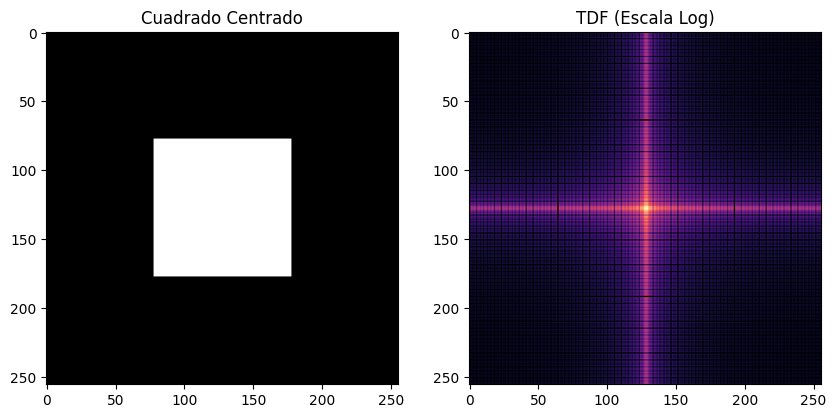

In [4]:

size = 256

img = np.zeros((size, size))

c = size // 2
r = 50  
img[c-r:c+r, c-r:c+r] = 1


f_transform = np.fft.fft2(img)
f_shift = np.fft.fftshift(f_transform)

magnitude = np.log(1 + np.abs(f_shift))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Cuadrado Centrado')
plt.subplot(122), plt.imshow(magnitude, cmap='magma'), plt.title('TDF (Escala Log)')
plt.show()

In [5]:
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

fig = go.Figure(
    data=[
        go.Surface(
            z=magnitude,
            x=X,
            y=Y
        )
    ]
)

fig.update_layout(
    title="Magnitud de la FFT (3D)",
    scene=dict(
        xaxis_title="Frecuencia X",
        yaxis_title="Frecuencia Y",
        zaxis_title="Magnitud"
    ),
    width=800,
    height=700
)

fig.show()

## Rectangulo centrado
EL rectangulo es mas ancho que alto entonces:
- frecuencias horizontales: Analizamos un perfil vertical, da un pulso rectangular pequeño. Esto implica que en esa direccion perpendicular, habrá una sinc que oscile poco.
- Frecuencias verticales: hay, dedberiamos ver una sinc sobre el eje perpendicular de la transformada mas pequeño por analizar el perfil

El resultado, una transformada 

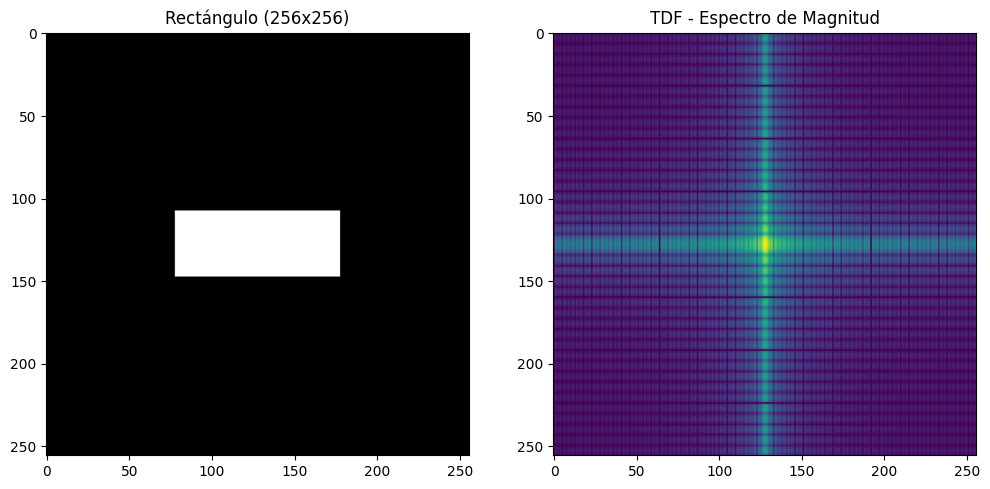

In [6]:

size = 256
img = np.zeros((size, size))

centro = size // 2
ancho_mitad, alto_mitad = 50, 20

img[centro - alto_mitad : centro + alto_mitad, 
    centro - ancho_mitad : centro + ancho_mitad] = 1

f_transform = np.fft.fft2(img)
f_shift = np.fft.fftshift(f_transform)

magnitude = np.log(1 + np.abs(f_shift))

# Visualización
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Rectángulo (256x256)')
plt.subplot(122), plt.imshow(magnitude, cmap='viridis'), plt.title('TDF - Espectro de Magnitud')
plt.show()

In [7]:
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

fig = go.Figure(
    data=[
        go.Surface(
            z=magnitude,
            x=X,
            y=Y
        )
    ]
)

fig.update_layout(
    title="Magnitud de la FFT (3D)",
    scene=dict(
        xaxis_title="Frecuencia X",
        yaxis_title="Frecuencia Y",
        zaxis_title="Magnitud"
    ),
    width=800,
    height=700
)

fig.show()

## circulo centrado



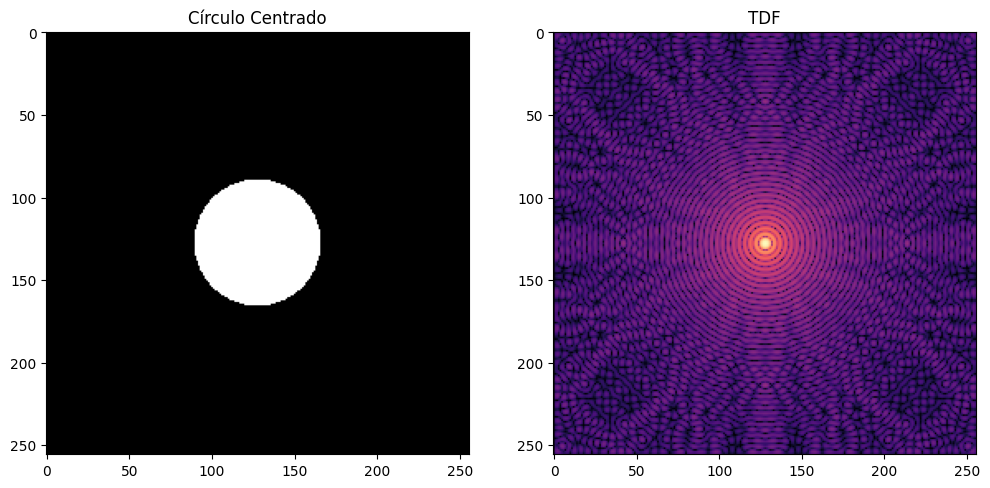

In [8]:

size = 256
x = np.linspace(-1, 1, size)
y = np.linspace(-1, 1, size)
X, Y = np.meshgrid(x, y)


dist = np.sqrt(X**2 + Y**2)
img = np.where(dist < 0.3, 1.0, 0.0)


f_transform = np.fft.fft2(img)
f_shift = np.fft.fftshift(f_transform)


magnitude = np.log(1 + np.abs(f_shift))


plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title('Círculo Centrado')
plt.subplot(122), plt.imshow(magnitude, cmap='magma'), plt.title('TDF')
plt.show()

In [9]:
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

fig = go.Figure(
    data=[
        go.Surface(
            z=magnitude,
            x=X,
            y=Y
        )
    ]
)

fig.update_layout(
    title="Magnitud de la FFT (3D)",
    scene=dict(
        xaxis_title="Frecuencia X",
        yaxis_title="Frecuencia Y",
        zaxis_title="Magnitud"
    ),
    width=800,
    height=700
)

fig.show()

# ejercicio 3

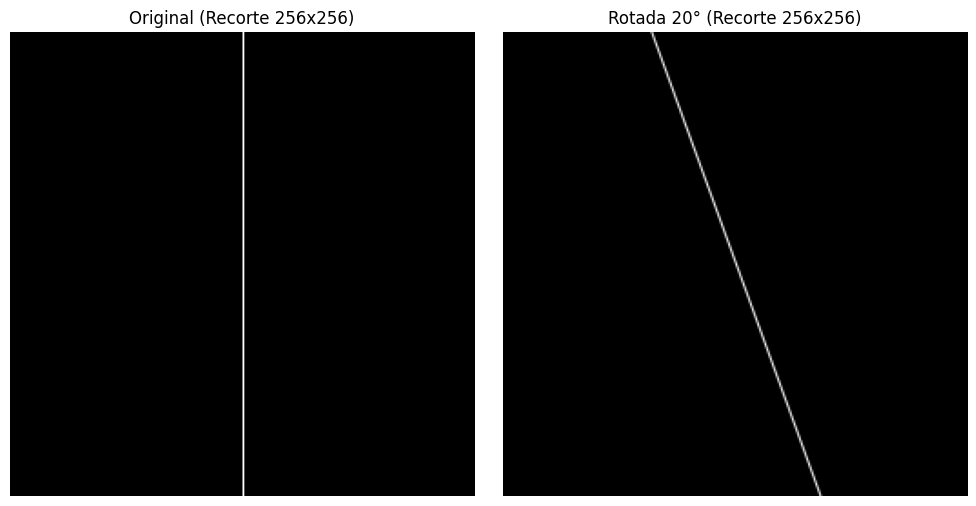

In [10]:

size = 512
img = np.zeros((size, size), dtype=np.uint8)

cv2.line(img, (size // 2, 0), (size // 2, size), 255, 1)

#rotacion
center = (size // 2, size // 2) #respecto al centro geometrico de la imagen
angle = 20
scale = 1.0
matrix = cv2.getRotationMatrix2D(center, angle, scale) #me da la matriz para hacer tal rotacion.

# Aplicamos la rotación a la imagen.
img_rotated = cv2.warpAffine(img, matrix, (size, size), flags=cv2.INTER_LINEAR)

# 
start = size // 2 - 128
end = size // 2 + 128

crop_original = img[start:end, start:end]
crop_rotated = img_rotated[start:end, start:end]

# 4. visualizacion
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Imagen Original
axes[0].imshow(crop_original, cmap='gray')
axes[0].set_title("Original (Recorte 256x256)")
axes[0].axis('off') # Ocultar ejes

# Imagen Rotada
axes[1].imshow(crop_rotated, cmap='gray')
axes[1].set_title("Rotada 20° (Recorte 256x256)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

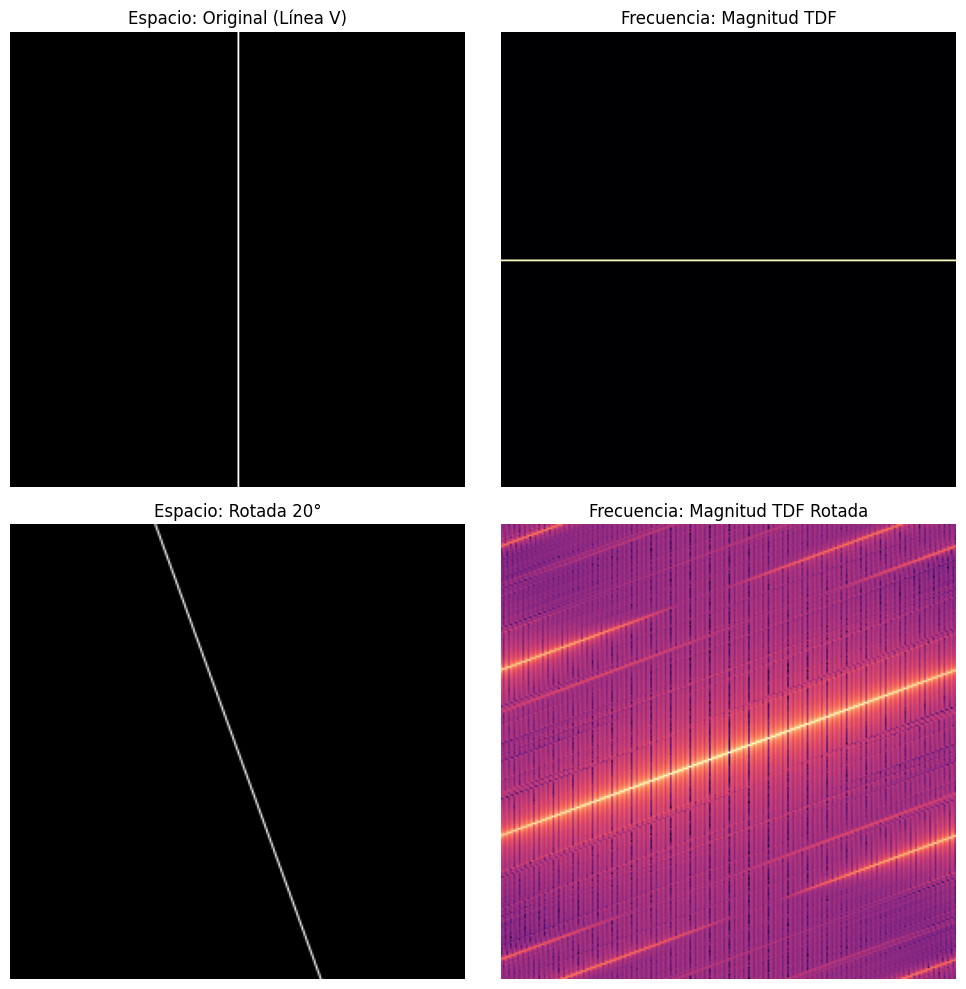

In [11]:
freq_or = np.fft.fft2(crop_original)
freq_or_shift = np.fft.fftshift(freq_or)

freq_rot = np.fft.fft2(crop_rotated)
freq_rot_shift = np.fft.fftshift(freq_rot)


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Fila 1: Original
axes[0, 0].imshow(crop_original, cmap='gray')
axes[0, 0].set_title("Espacio: Original (Línea V)")
axes[0, 1].imshow(np.log(np.abs(freq_or_shift)+1), cmap='magma')
axes[0, 1].set_title("Frecuencia: Magnitud TDF")

# Fila 2: Rotada
axes[1, 0].imshow(crop_rotated, cmap='gray')
axes[1, 0].set_title("Espacio: Rotada 20°")
axes[1, 1].imshow(np.log(np.abs(freq_rot_shift)+1), cmap='magma')
axes[1, 1].set_title("Frecuencia: Magnitud TDF Rotada")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


El resultado tiene algo de sentido porque al rotar la imagen, el espacio dejo de ser vertical solamente y ahora tiene variaciones horizontales y verticales.


Al rotar 20 grados en el espacio, el espectro se roto 20 grados.

In [12]:
graph_fft_3d(256, 256, np.log(np.abs(freq_rot_shift)+1))